# Preprocessing & Pipelines

## Import Packages

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_qqplot import pplot
import numpy as np
from ydata_profiling import ProfileReport
import random

In [2]:
from scipy import stats
import statsmodels.formula.api as smf
from scipy.stats import f_oneway

In [3]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    QuantileTransformer,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures,
    FunctionTransformer,
    PowerTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

## File Directories

In [5]:
INPUT_DIR = os.path.join("../input")

In [6]:
OUTPUT_DIR = os.path.join("../output")

In [7]:
TEMP_DIR = os.path.join("../temp")

In [8]:
FILE_DIR = os.path.join("../input")

## Load Data

In [998]:
df_superstore = pd.read_csv(os.path.join(OUTPUT_DIR,"merged_superstore_dfv2.csv"))

In [999]:
df_superstore["num_returned"] = (df_superstore["Returned"] == "Yes").astype(int)

## Prepare

In [22]:
#df_superstorev2 = df_superstorev2[df_superstorev2["Market"] == "US"]

In [1002]:
train_dfv2, test_dfv2 = train_test_split(df_superstore, random_state=42)

In [974]:
np.random.randn(42)
random.seed(42)

In [980]:
train_dfv2.columns

Index(['Unnamed: 0', 'product_id', 'num_returned', 'Quantity', 'Discount',
       'order_to_ship_date', 'Furniture', 'Office Supplies', 'Technology',
       'Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs',
       'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels',
       'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables', 'APAC',
       'Africa', 'Canada', 'EMEA', 'EU', 'LATAM', 'US', 'Order ID',
       'artikel_pro_bestellung_mean', 'anzahl_an_kunden',
       'quantity_per_cutstomer', 'retouren_quote'],
      dtype='object')

In [28]:
train_df = train_df.rename(
    columns={
        "shipping-cost": "shipping_cost",
        "Order Date": "order_date",
        "Postal Code": "postal_code",
        "Sub-Category": "sub_category",
        "Product Name": "product_name",
        "Shipping Cost":"shipping_cost",
        "Order Priority": "order_priority",
        "Ship Date": "ship_date",
        "Ship Mode": "ship_mode",
        "Customer Name": "customer_name",
        "Customer ID": "customer_id",
        "Row ID": "row_id",
        "Order ID": "order_id",
    }
)

### Variable Lists

In [33]:
target_col = ["num_returned"]

In [35]:
cat_features_col = ["Segment","sub_category", "Category", "Market", "Country", "Region", "product_name", "order_priority"]

In [190]:
num_features_col = ["Quantity", "Discount", "order_to_ship_date", "Sales","Profit", "order_to_ship_date", "shipping_cost"]

**NOTE:**

---

- Im Folgenden identifizieren wir mit ANOVA kategoriale Variablen, deren Gruppen signifikante Unterschiede in der mittleren Retourenrate aufweisen.

ANOVA:

- Wir nutzen hierfür die ANOVA als Werkzeug und prüfen die Differenz der Mittelwerte der selektierten Variablen gegen das Target.


Variationskoeffizient:

- Von den selektierten Merkmalen berechnen wir die Variationskoeffizienten der Ausprägungen.
- Zum Schluss filtern wir den Datensatz nach den Ausprägungen mit dem niedrigsten Variationskoeffizienten.



---

#### ANOVA

##### Kategoriale Variable

In [957]:
def anova(df, var):
    
    kategorien = df[var].unique()
    
    gruppen_liste = [df[df[var] == kat]["num_returned"] for kat in kategorien]
    
    f_statistic, p_value = f_oneway(*gruppen_liste)
    
    return f_statistic, p_value

In [959]:
for m in cat_features_col:
    merkmal = m

    f_statistic, p_value = anova(train_df, merkmal)

    print(f"{merkmal}: {p_value}")
    print(f"{merkmal}: {f_statistic}")

Segment: 0.08194141431762371
Segment: 2.5019134539861096
sub_category: 7.2666787334430356e-06
sub_category: 3.320471581475058
Category: 0.0713148529205847
Category: 2.6408319341597384
Market: 1.5698159612203132e-131
Market: 104.8382396053025
Country: 9.822696816157368e-277
Country: 12.387015260214305
Region: 0.0
Region: 145.44651176700904
product_name: 1.93473609959963e-09
product_name: 1.1506911440994978
order_priority: 0.4865009073002998
order_priority: 0.8128615570500939


In [341]:
#für die neue Variable cat_discount
anova(train_dfv2, "cat_discount")

0.00015007227501556206

##### Numerische Variable

In [182]:
def anova_num (var):
    
    returned_df = train_dfv2[train_dfv2["Returned"] == "Yes"]
    not_returned_df = train_dfv2[train_dfv2["Returned"] == "No"]
    
    group_one = returned_df[var]
    group_two = not_returned_df[var]
    
    return f_oneway(group_one, group_two)

In [961]:
for n in num_features_col:

    numeric_var = n
    f_statistic, p_value = anova_num(numeric_var)
    
    print(f"{numeric_var}: {p_value}, {f_statistic}")

Quantity: 0.0007342577704398066, 11.402744246228547
Discount: 2.2387530138517276e-09, 35.77517434826324
order_to_ship_date: 0.010602655702905235, 6.531521284024548
Sales: 0.1190162213547276, 2.4303541064756558
Profit: 0.0036047280804185, 8.474212303965057
order_to_ship_date: 0.010602655702905235, 6.531521284024548
shipping_cost: 0.12005496876594673, 2.4167368493731116


#### Variationskoeffizient

In [222]:
selected_num_var = ["Quantity","Discount", "order_to_ship_date", "Profit"]

In [229]:
def variationskoeffizient_berechnen(numerische_variable):
    var_koef= (train_dfv2[value].std() / train_dfv2[value].mean()) * 100
    
    return var_koef

In [231]:
for s in selected_num_var:

    value = s
    
    var_koef_value = variationskoeffizient_berechnen(value)
    
    print(f"{s}: {var_koef_value}")

Quantity: 59.14100710003848
Discount: 139.1227723486289
order_to_ship_date: 43.52673103677872
Profit: 571.8006114325464


In [996]:
train_dfv2.columns

Index(['Unnamed: 0', 'product_id', 'num_returned', 'Quantity', 'Discount',
       'order_to_ship_date', 'Furniture', 'Office Supplies', 'Technology',
       'Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs',
       'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels',
       'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables', 'APAC',
       'Africa', 'Canada', 'EMEA', 'EU', 'LATAM', 'US', 'Order ID',
       'artikel_pro_bestellung_mean', 'anzahl_an_kunden',
       'quantity_per_cutstomer', 'retouren_quote'],
      dtype='object')

In [994]:
train_dfv2["Profit"].sum()

KeyError: 'Profit'

## Verteilung analysieren

### Kategoriale Variable

#### `Market`

In [136]:
## Market die keine Retouren-Fälle verzeichnen, werden aus dem Datensatz entfernt: Africa, Canada, EMEA

In [84]:
crosstab_market_returned = pd.crosstab(train_df["Market"], train_df["num_returned"],normalize = "index")*100

<Axes: xlabel='Market'>

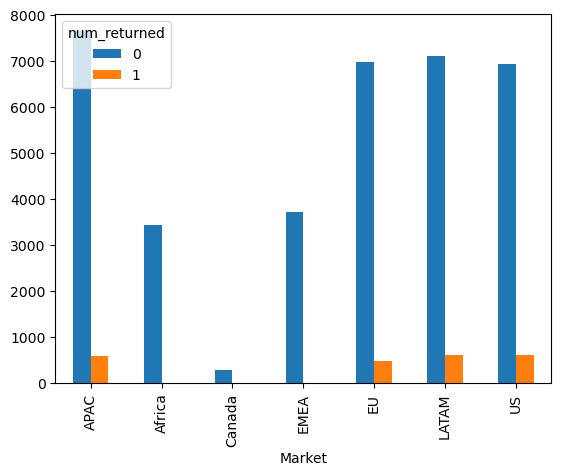

In [80]:
crosstab_market_returned.plot.bar()

In [86]:
crosstab_market_returned

num_returned,0,1
Market,,
APAC,92.756612,7.243388
Africa,100.000000,0.000000
Canada,100.000000,0.000000
EMEA,100.000000,0.000000
EU,93.600214,6.399786
LATAM,91.905870,8.094130
US,91.913711,8.086289


In [90]:
### Africa, Canada, EMEA eliminieren

#### `Category`

In [105]:
crosstab_category_returned = pd.crosstab(train_df["Category"], train_df["Returned"],normalize = "index")*100

<Axes: xlabel='Category'>

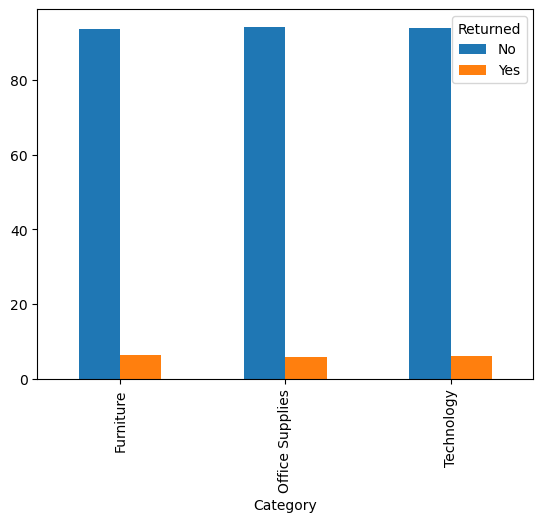

In [107]:
crosstab_category_returned.plot.bar()

In [109]:
crosstab_category_returned

Returned,No,Yes
Category,,
Furniture,93.536684,6.463316
Office Supplies,94.205496,5.794504
Technology,93.770578,6.229422


#### `order_priority`

In [118]:
crosstab_order_priority_returned = pd.crosstab(train_df["order_priority"], train_df["Returned"],normalize = "index")*100

<Axes: xlabel='order_priority'>

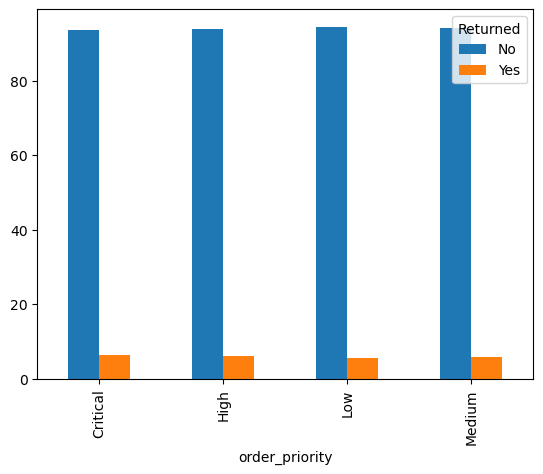

In [120]:
crosstab_order_priority_returned.plot.bar()

In [122]:
crosstab_order_priority_returned

Returned,No,Yes
order_priority,,
Critical,93.508712,6.491288
High,93.853835,6.146165
Low,94.347826,5.652174
Medium,94.096075,5.903925


### Numerische Variable

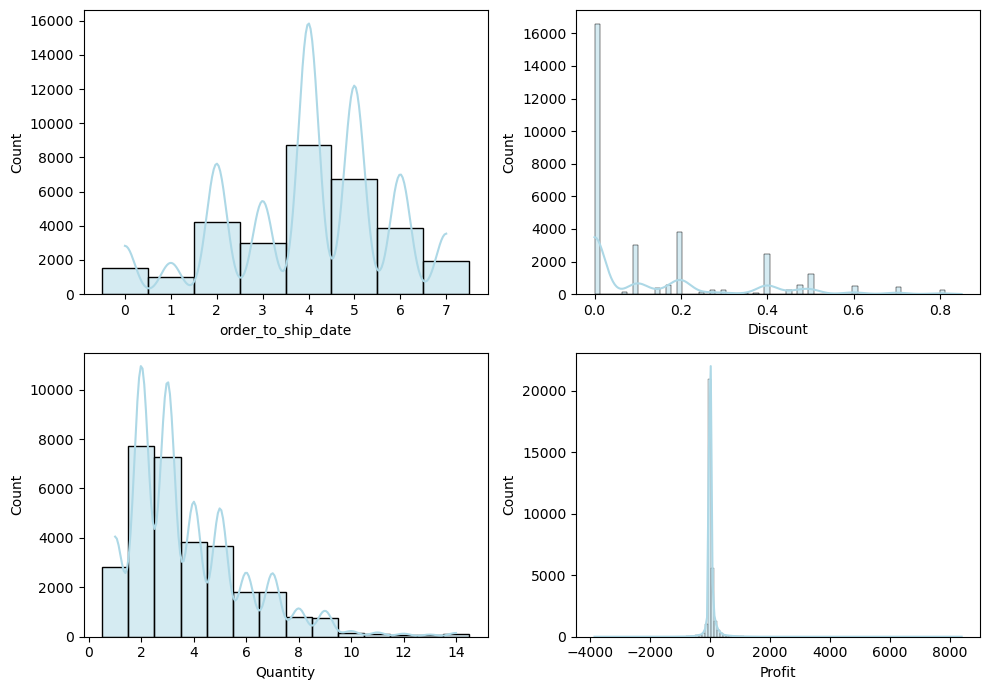

In [280]:
fig, ax = plt.subplots(2,2, figsize=(10, 7))

sns.histplot(train_dfv2["order_to_ship_date"], discrete=True, ax=ax[0,0], color="lightblue", kde=True)
sns.histplot(train_dfv2["Discount"], ax=ax[0,1], color="lightblue", kde=True)
sns.histplot(train_dfv2["Quantity"], discrete=True, ax=ax[1,0], color="lightblue", kde=True)
sns.histplot(train_dfv2["Profit"], ax=ax[1,1], bins = 120, color="lightblue", kde=True)

plt.tight_layout()

**Note**:

---

`oder_to_ship_date`:

- Aufgrund des niedrigen Variationskoeffizienten und der inhaltlichen Interpretierbarkeit der Variable wird auf eine Transformation verzichtet

`Discount`

- Zero-Inflated
- Hat mehr Charaktereigenschaften einer Kategoriale Variable
- Wird zu einer kategoriale Variable transformiert

`Quantity`

- Rechtsschiefe Verteilung
- Anwendung von Power-Transformer (Box-Cox)

`Profit`

- Extreme Spitze am Null-Punkt (Leptokurtosis)
- Symetrische Verteilung mit einer Glockenkurve

---

## Pipelines

### ColumnTransformer

In [653]:
new_num_features = ["order_to_ship_date","Quantity", "Profit"]

In [655]:
new_cat_features = ["Category", "sub_category", "cat_discount", "order_priority", "Market"]

In [690]:
def prepare_for_pipeline(df):
    print("Original shape:", df.shape)
    df = df[new_cat_features + new_num_features + ["num_returned"]].dropna()
    print("Shape after dropna():", df.shape)
    x = df[new_cat_features + new_num_features]
    y = df[["num_returned"]]
    print("Shape after feature selection:", x.shape)
    return x, y

In [659]:
x_trained, y_trained = prepare_for_pipeline(train_dfv2)

Original shape: (31001, 29)
Shape after dropna(): (31001, 9)
Shape after feature selection: (31001, 8)


In [661]:
quantile_transformer_pipelines = Pipeline(
    [
        ("quantile_transformer", QuantileTransformer()),
        ("std_scaler", StandardScaler()),
    ]
)

In [663]:
power_transformer_boxcox_pipelines = Pipeline(
    [
        ("power_boxcox", PowerTransformer(method="box-cox")),
        ("std_scaler", StandardScaler()),
    ]
)

In [665]:
col_transform_pipeline = ColumnTransformer(
    [
        ("quantile_transformer", quantile_transformer_pipelines,["Profit"]),
        ("power_boxcox", power_transformer_boxcox_pipelines, ["Quantity"]),
        ("onehot_transformer", OneHotEncoder(), ["Category", "sub_category", "Market"]),
        ("ordinal_transformer", OrdinalEncoder(), ["order_priority", "cat_discount" ]),
        ("std_scaler", StandardScaler(), ["order_to_ship_date"])
        
        
    ]
)

## Prepare Trainig-Set

In [668]:
col_transformed_var = col_transform_pipeline.fit_transform(x_trained)

In [670]:
print(col_transformed_var.shape)

(31001, 29)


**Array-Output von der Pipeline `transform_pipeline` in DataFrame transformieren**

In [673]:
def array_to_df(list_array, col_names):
    
    new_df = pd.DataFrame(list_array, columns=col_names)
    new_df = new_df.reset_index(drop=True)
    
    return new_df

In [675]:
x_col_names = col_transform_pipeline.get_feature_names_out()

In [677]:
transformed_train_dfv2 = array_to_df(col_transformed_var.toarray(), x_col_names)

In [679]:
transformed_train_dfv2.columns

Index(['quantile_transformer__Profit', 'power_boxcox__Quantity',
       'onehot_transformer__Category_Furniture',
       'onehot_transformer__Category_Office Supplies',
       'onehot_transformer__Category_Technology',
       'onehot_transformer__sub_category_Accessories',
       'onehot_transformer__sub_category_Appliances',
       'onehot_transformer__sub_category_Art',
       'onehot_transformer__sub_category_Binders',
       'onehot_transformer__sub_category_Bookcases',
       'onehot_transformer__sub_category_Chairs',
       'onehot_transformer__sub_category_Copiers',
       'onehot_transformer__sub_category_Envelopes',
       'onehot_transformer__sub_category_Fasteners',
       'onehot_transformer__sub_category_Furnishings',
       'onehot_transformer__sub_category_Labels',
       'onehot_transformer__sub_category_Machines',
       'onehot_transformer__sub_category_Paper',
       'onehot_transformer__sub_category_Phones',
       'onehot_transformer__sub_category_Storage',
       

<Axes: xlabel='quantile_transformer__Profit', ylabel='Count'>

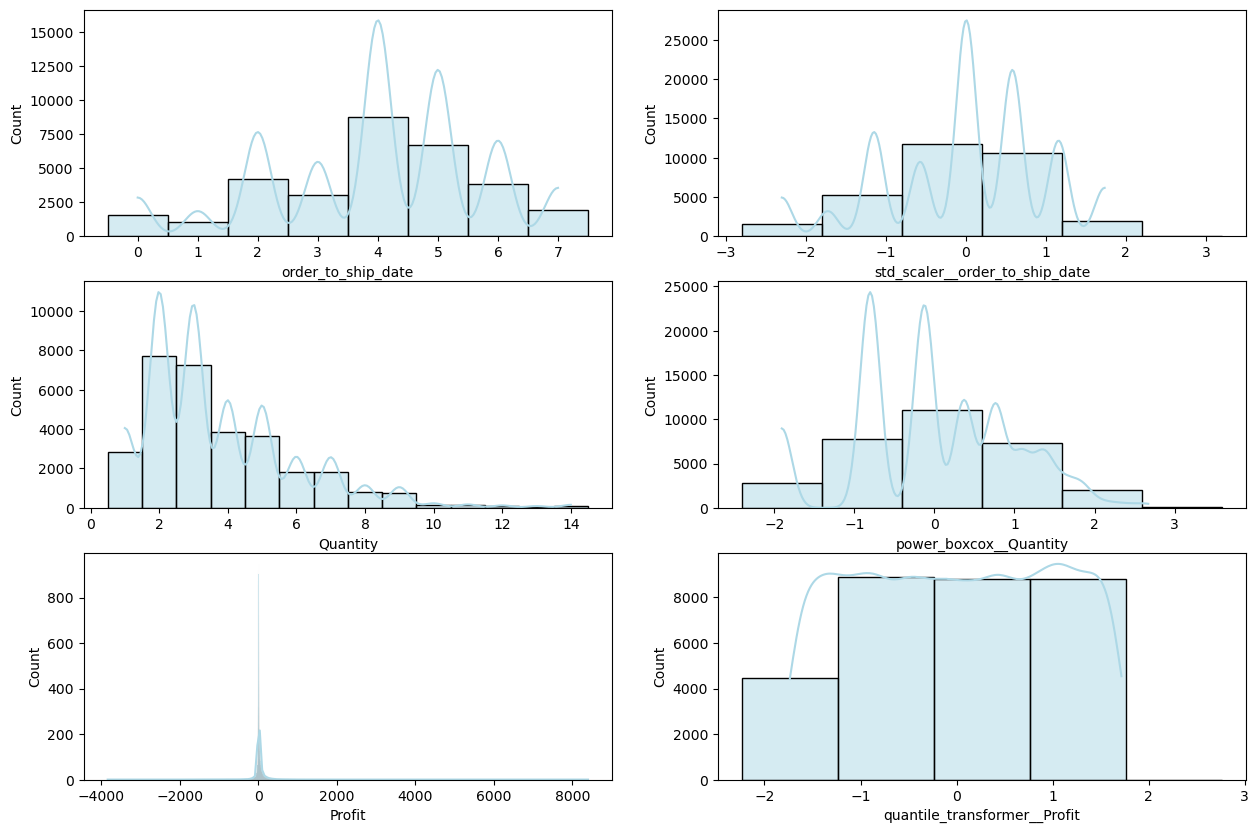

In [681]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

### order_to_ship_date
sns.histplot(x_trained["order_to_ship_date"], discrete = True, ax=ax[0,0], color="lightblue", kde=True)
sns.histplot(transformed_train_dfv2["std_scaler__order_to_ship_date"], discrete = True, ax=ax[0,1], color="lightblue", kde=True)

### Quantity
sns.histplot(x_trained["Quantity"], discrete = True, ax=ax[1,0],color="lightblue", kde=True)
sns.histplot(transformed_train_dfv2["power_boxcox__Quantity"], discrete = True, ax=ax[1,1], color="lightblue", kde=True)


### Profit
sns.histplot(x_trained["Profit"], ax=ax[2,0], discrete = True, color="lightblue", kde=True)
sns.histplot(transformed_train_dfv2["quantile_transformer__Profit"], discrete = True, ax=ax[2,1], color="lightblue", kde=True)


## Prepare Trainig-Set

In [708]:
test_dfv2.columns

Index(['Unnamed: 0', 'row_id', 'order_id', 'order_date', 'ship_date',
       'ship_mode', 'customer_id', 'customer_name', 'Segment', 'City', 'State',
       'Country', 'postal_code', 'Market', 'Region', 'Product ID', 'Category',
       'sub_category', 'product_name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'shipping_cost', 'order_priority', 'Returned',
       'order_to_ship_date', 'num_returned', 'cat_discount'],
      dtype='object')

In [796]:
x_test, y_test = prepare_for_pipeline(test_dfv2)

Original shape: (10294, 29)
Shape after dropna(): (10294, 9)
Shape after feature selection: (10294, 8)


In [798]:
col_transformed_test_var = col_transform_pipeline.fit_transform(x_test)

In [800]:
x_test_col_names = col_transform_pipeline.get_feature_names_out()

In [802]:
transformed_test_dfv2 = array_to_df(col_transformed_test_var.toarray(), x_test_col_names)

<Axes: xlabel='quantile_transformer__Profit', ylabel='Count'>

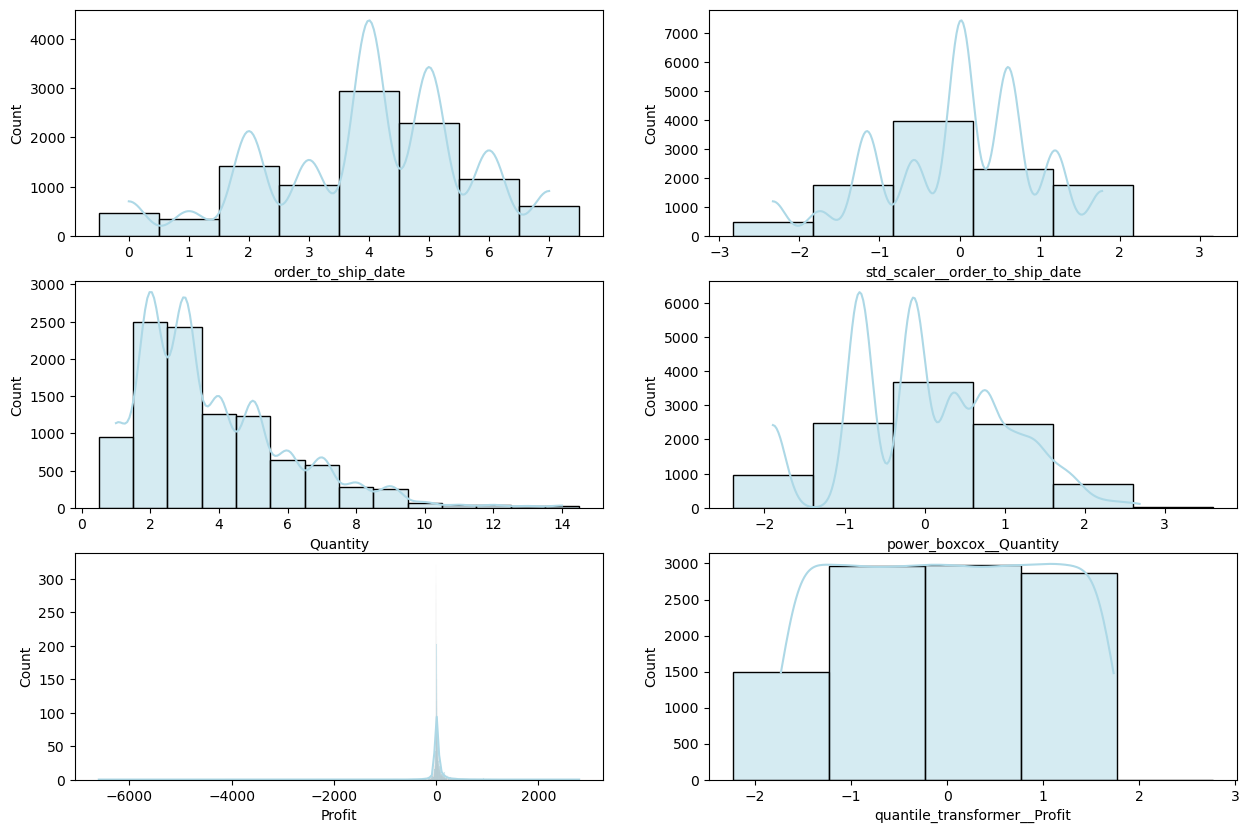

In [804]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

### order_to_ship_date
sns.histplot(x_test["order_to_ship_date"], discrete = True, ax=ax[0,0], color="lightblue", kde=True)
sns.histplot(transformed_test_dfv2["std_scaler__order_to_ship_date"], discrete = True, ax=ax[0,1], color="lightblue", kde=True)

### Quantity
sns.histplot(x_test["Quantity"], discrete = True, ax=ax[1,0],color="lightblue", kde=True)
sns.histplot(transformed_test_dfv2["power_boxcox__Quantity"], discrete = True, ax=ax[1,1], color="lightblue", kde=True)


### Profit
sns.histplot(x_test["Profit"], ax=ax[2,0], discrete = True, color="lightblue", kde=True)
sns.histplot(transformed_test_dfv2["quantile_transformer__Profit"], discrete = True, ax=ax[2,1], color="lightblue", kde=True)


## Logistische Regression

In [727]:
from sklearn.linear_model import LogisticRegression

In [809]:
logreg = LogisticRegression(random_state=42,class_weight='balanced')
m = logreg.fit(transformed_train_dfv2, y_trained)
m.score(transformed_train_dfv2, y_trained)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.5455953033773104

In [811]:
m.score(transformed_test_dfv2, y_test)

0.5463376724305421

In [813]:
from sklearn.metrics import f1_score, roc_auc_score

y_pred = logreg.predict(transformed_test_dfv2)

print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, logreg.predict_proba(transformed_test_dfv2)[:, 1]))

F1-Score: 0.1390117994100295
ROC-AUC: 0.5315551858528693


## Entscheidungsbäume

In [1012]:
from sklearn.tree import DecisionTreeClassifier

In [1018]:
dtclass2 = DecisionTreeClassifier(max_depth=15, class_weight='balanced')
m2 = dtclass2.fit(transformed_train_dfv2, y_trained)
m2.score(transformed_train_dfv2, y_trained)

0.6418502628947453

In [1020]:
m2.score(transformed_test_dfv2, y_test)

ValueError: Found input variables with inconsistent numbers of samples: [2262, 10294]

In [910]:
dtclass2_y_pred = dtclass2.predict(transformed_test_dfv2)

print("F1-Score:", f1_score(y_test, dtclass2_y_pred))
print("ROC-AUC:", roc_auc_score(y_test, dtclass2.predict_proba(transformed_test_dfv2)[:, 1]))

F1-Score: 0.1361150496252785
ROC-AUC: 0.5273324772176513


## KNN

In [924]:
from sklearn.neighbors import KNeighborsClassifier

In [943]:
neigh = KNeighborsClassifier(n_neighbors=11)
m3 = neigh.fit(transformed_train_dfv2, y_trained)

print(m3.predict(transformed_test_dfv2))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


[0 0 0 ... 0 0 0]


In [944]:
neigh_y_pred = neigh.predict(transformed_test_dfv2)

print("F1-Score:", f1_score(y_test, neigh_y_pred))
print("ROC-AUC:", roc_auc_score(y_test, neigh.predict_proba(transformed_test_dfv2)[:, 1]))

F1-Score: 0.00267379679144385
ROC-AUC: 0.5254380640981975


In [320]:
superstore_product_df

,Unnamed: 0,Product ID,num_returned,Quantity,Discount,order_to_ship_date,Furniture,Office Supplies,Technology,Accessories,...,Canada,EMEA,EU,LATAM,US,order_id,artikel_pro_bestellung_mean,anzahl_an_kunden,quantity_per_cutstomer,retouren_quote
0,0,FUR-ADV-10000108,0,1,0.00,7,1,0,0,0,...,0,0,0,0,0,1,2.00,1,1.00,0.0
1,1,FUR-ADV-10000183,0,9,0.00,3,4,0,0,0,...,0,2,0,0,0,4,1.75,4,2.25,0.0
2,2,FUR-ADV-10000188,0,3,0.35,4,2,0,0,0,...,0,1,0,0,0,2,3.00,2,1.50,0.0
3,3,FUR-ADV-10000190,0,2,0.00,0,1,0,0,0,...,0,1,0,0,0,1,9.00,1,2.00,0.0
4,4,FUR-ADV-10000571,0,13,0.00,4,4,0,0,0,...,0,3,0,0,0,4,2.25,4,3.25,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,9042,TEC-STA-10004181,0,10,0.12,4,0,0,5,0,...,1,2,0,0,0,5,2.80,5,2.00,0.0
9043,9043,TEC-STA-10004536,0,2,0.00,4,0,0,2,0,...,0,0,0,0,0,2,1.50,2,1.00,0.0
9044,9044,TEC-STA-10004542,0,2,0.00,1,0,0,1,0,...,0,1,0,0,0,1,1.00,1,2.00,0.0
9045,9045,TEC-STA-10004834,0,5,0.65,5,0,0,2,0,...,0,1,0,0,0,2,2.00,2,2.50,0.0


In [374]:
df_superstore["returned_num"]= df_superstore["Returned"].map({'Yes': 1, 'No': 0})

In [376]:
df_superstore.head()

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Returned,order_to_ship_date,num_returned,returned_num
0,0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,...,2309.650,7,0.0,762.1845,933.57,Critical,No,0,0,0
1,2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,...,5175.171,9,0.1,919.9710,915.49,Medium,No,1,0,0
2,4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,...,2832.960,8,0.0,311.5200,903.04,Critical,No,1,0,0
3,6,30570,IN-2011-81826,2011-11-07,2011-11-09,First Class,TS-21340,Toby Swindell,Consumer,Porirua,...,1822.080,4,0.0,564.8400,894.77,Critical,No,2,0,0
4,7,31192,IN-2012-86369,2012-04-14,2012-04-18,Standard Class,MB-18085,Mick Brown,Consumer,Hamilton,...,5244.840,6,0.0,996.4800,878.38,High,No,4,0,0


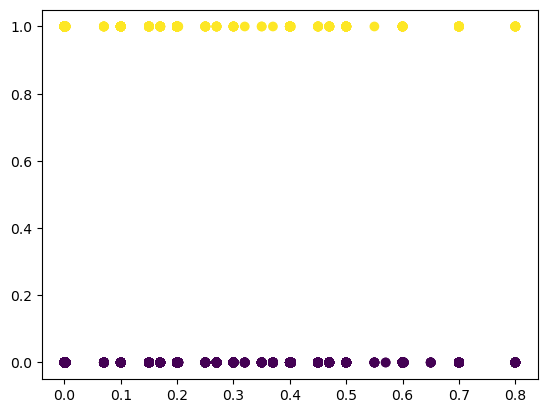

In [384]:

x = df_superstore["Discount"]
y = df_superstore["num_returned"]
classes = df_superstore["returned_num"]

plt.scatter(x, y, c=classes)
plt.show()

## Transform

In [147]:
train_dfv2 = train_df.loc[train_df["Market"].isin(["APAC", "EU", "LATAM", "US"])]

In [782]:
test_dfv2 = test_df.loc[test_df["Market"].isin(["APAC", "EU", "LATAM", "US"])]

### Transform `Discount` to category Variable

<Axes: xlabel='Discount', ylabel='Count'>

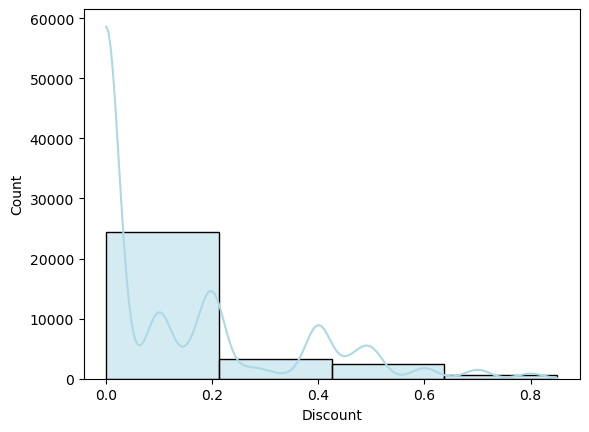

In [295]:
sns.histplot(train_dfv2["Discount"], bins = 4, color="lightblue", kde=True)

In [323]:
def set_class(d_value):
    if (d_value >= 0) & (d_value < 0.2):
        return "no_discount"
    elif (d_value >= 0.2) & (d_value <= 0.4):
        return "low_discount"
    elif (d_value >= 0.4) & (d_value <= 0.6):
        return "medium_discount"
    else:
        return "high_discount"

In [335]:
train_dfv2["cat_discount"] = train_dfv2["Discount"].apply(set_class)

/var/folders/js/_xy2g5lx3x9bmk2ldqbkrm080000gq/T/ipykernel_74765/2790077479.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_dfv2["cat_discount"] = train_dfv2["Discount"].apply(set_class)


In [792]:
test_dfv2["cat_discount"] = test_dfv2["Discount"].apply(set_class)

In [794]:
test_dfv2.head(3)

,Unnamed: 0,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,Segment,City,...,Sales,Quantity,Discount,Profit,shipping_cost,order_priority,Returned,order_to_ship_date,num_returned,cat_discount
30040,30040,35785,CA-2012-162621,2012-09-05,2012-09-11,Standard Class,CA-12055,Cathy Armstrong,Home Office,Houston,...,69.120,9,0.2,-14.688,5.480,Medium,No,6,0,low_discount
44906,44906,14631,ES-2014-2873001,2014-04-17,2014-04-23,Standard Class,MH-18025,Michelle Huthwaite,Consumer,Hayange,...,31.200,1,0.0,4.050,1.250,Medium,No,6,0,no_discount
27274,27274,5039,US-2014-167430,2014-09-01,2014-09-06,Second Class,SS-20410,Shahid Shariari,Consumer,Maracay,...,97.272,2,0.4,-17.848,6.841,Medium,No,5,0,low_discount


In [784]:
test_dfv2["Market"].value_counts()

Market
APAC     2760
LATAM    2563
EU       2531
US       2440
Name: count, dtype: int64

In [788]:
test_dfv2 = test_dfv2.rename(
    columns={
        "shipping-cost": "shipping_cost",
        "Order Date": "order_date",
        "Postal Code": "postal_code",
        "Sub-Category": "sub_category",
        "Product Name": "product_name",
        "Shipping Cost":"shipping_cost",
        "Order Priority": "order_priority",
        "Ship Date": "ship_date",
        "Ship Mode": "ship_mode",
        "Customer Name": "customer_name",
        "Customer ID": "customer_id",
        "Row ID": "row_id",
        "Order ID": "order_id",
    }
)